# Market volatility model and dynamic exposure strategy

Two series are kept separate from start to finish:

- `_MKT`: the raw market index. We trade on it and all P&L is measured from it.
- `VOL{WINDOW}w_MKT`: realized volatility of `_MKT` over the next `WINDOW` weeks. This is the prediction target.

The model forecasts forward volatility. The forecast sets exposure (high predicted vol means lower exposure). Trades and P&L always use `_MKT`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import torch
import pandas as pd
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from tqdm.auto import tqdm


In [2]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

SEED = 122
TEST_YEARS = 5
HORIZON = 1     # weeks used by the dlog feature transforms
WINDOW = 4      # forward window (weeks) for the vol target VOL{WINDOW}w_MKT

set_seed(SEED)
SEEDS = np.random.randint(1000, 10000, 50)


In [3]:
df = pd.read_excel(r"C:\Programming\ETH\SS26\ISQT26\final\playground\market_data.xlsx", sheet_name="US", engine="openpyxl", index_col=0)
namings = pd.read_excel(r"C:\Programming\ETH\SS26\ISQT26\final\playground\market_data.xlsx", sheet_name="legend", engine="openpyxl", index_col=0)


## Raw series


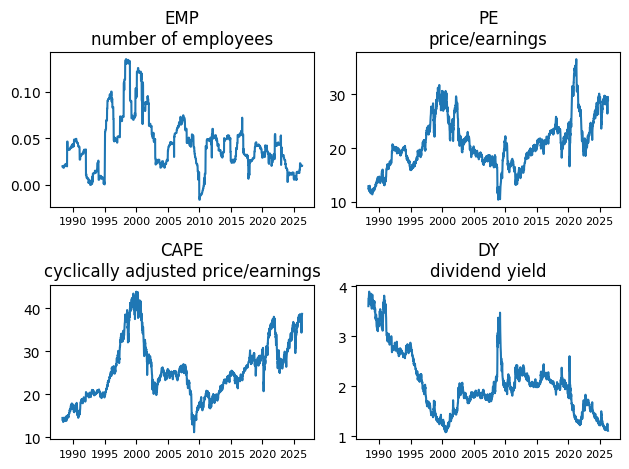

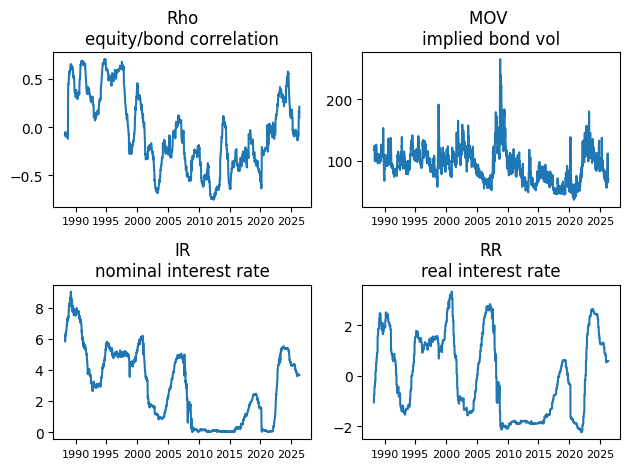

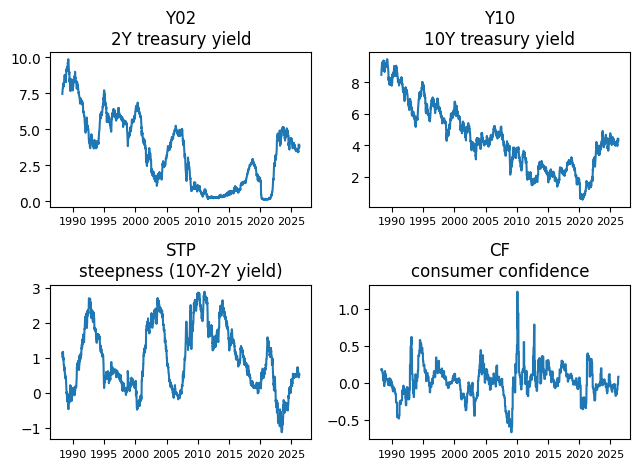

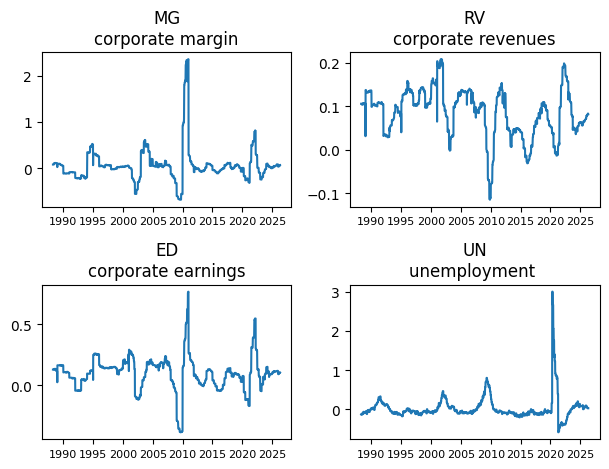

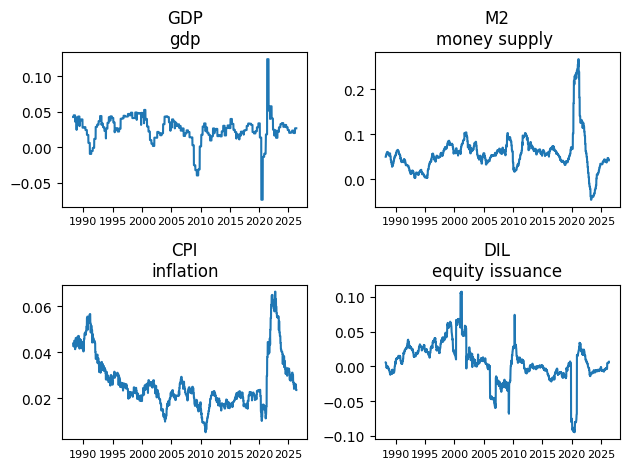

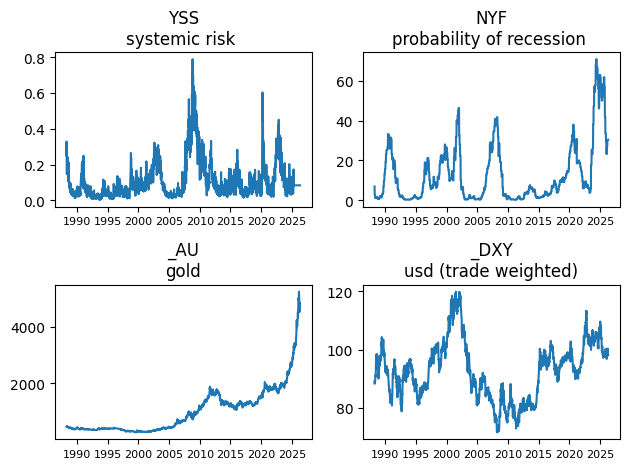

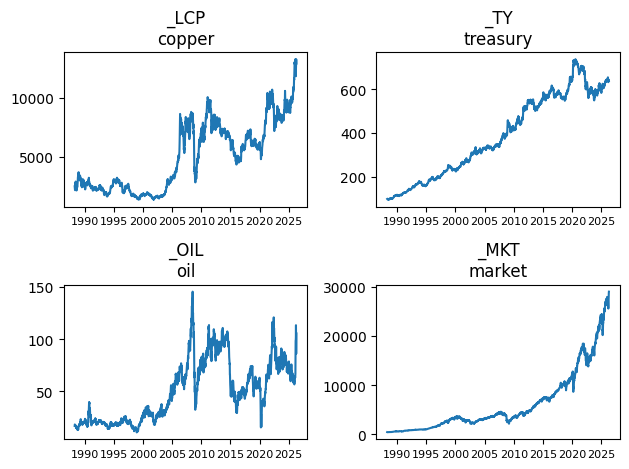

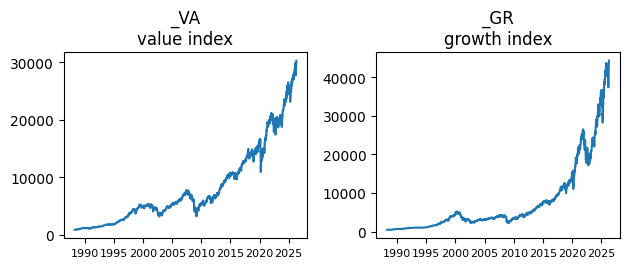

In [4]:
cols = list(df.columns)
for j, key in enumerate(cols):
    plt.subplot(2, 2, j % 4 + 1)
    plt.plot(df[key])
    desc = namings.loc[key, "Description"] if key in namings.index else ""
    plt.title(f"{key}\n{desc}")
    plt.xticks(fontsize=8)
    if j % 4 == 3 or j == len(cols) - 1:
        plt.tight_layout()
        plt.show()


## Features and target

`transform_data` builds the standardized feature block `Z` and the standardized
target `VOL{WINDOW}w_MKT`. The target is derived from the raw `_MKT` price, which
is dropped from the feature set so the level is not leaked. The same `_MKT` price
is reused later, unchanged, for trading.


In [5]:
def transform_data(X, price, params=None, horizon=1, window=4):
    '''
    Build standardized features Z and the standardized target VOL{window}w_MKT,
    the realized volatility of `price` over the next `window` weeks.
    `price` is the raw _MKT level: source of the vol target and, separately,
    the series we trade on.
    '''
    def safe_log(s):
        return np.log(s.where(s > 0))

    def dlog(s):
        return np.log(s / s.shift(horizon))

    def fisher(s):
        rho = s.clip(-1 + 1e-6, 1 - 1e-6)
        return np.arctanh(rho)

    def logit_prob(s):
        p = (s / 100).clip(1e-6, 1 - 1e-6)
        return np.log(p / (1 - p))

    def future_vol(s, w):
        r = np.log(s / s.shift(1))                            # weekly log returns
        return np.sqrt(r.pow(2).rolling(w).sum()).shift(-w)   # vol over next w weeks

    Z = pd.DataFrame(index=X.index)

    Z["EMP"]  = X["EMP"]
    Z["PE"]   = safe_log(X["PE"])
    Z["CAPE"] = safe_log(X["CAPE"])
    Z["DY"]   = safe_log(X["DY"])
    Z["Rho"]  = fisher(X["Rho"])
    Z["MOV "] = safe_log(X["MOV "])

    Z["IR"]   = X["IR"]
    Z["RR"]   = X["RR"]
    Z["Y02"]  = X["Y02"]
    Z["Y10"]  = X["Y10"]
    Z["STP"]  = X["STP"]

    Z["CF"]   = X["CF"]
    Z["MG"]   = X["MG"]
    Z["RV"]   = X["RV"]
    Z["ED"]   = X["ED"]
    Z["UN"]   = X["UN"]
    Z["GDP"]  = X["GDP"]
    Z["M2"]   = X["M2"]
    Z["CPI"]  = X["CPI"]
    Z["DIL"]  = X["DIL"]

    Z["YSS"]  = np.log1p(X["YSS"])
    Z["NYF"]  = logit_prob(X["NYF"])

    Z["_AU"]  = dlog(X["_AU"])
    Z["_DXY"] = dlog(X["_DXY"])
    Z["_LCP"] = dlog(X["_LCP"])
    Z["_TY"]  = dlog(X["_TY"])
    Z["_OIL"] = dlog(X["_OIL"])

    Z["_VA"]  = dlog(X["_VA"])
    Z["_GR"]  = dlog(X["_GR"])

    target_name = f"VOL{window}w_MKT"
    y = future_vol(price, window)
    y.name = target_name

    data = pd.concat([Z, y], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    Z = data.drop(columns=[target_name])
    y = data[target_name]

    if params is None:
        params = {
            "X_mean": Z.mean(),
            "X_std": Z.std(ddof=0).replace(0, 1),
            "Y_mean": y.mean(),
            "Y_std": y.std(ddof=0),
            "target_name": target_name,
        }

    Z = (Z - params["X_mean"]) / params["X_std"]
    y = (y - params["Y_mean"]) / params["Y_std"]

    return Z, y, params


def split_transform_data(df, price_col="_MKT", test_years=5, horizon=1, window=4):
    split_date = df.index.max() - pd.DateOffset(years=test_years)

    train = df.loc[df.index < split_date]
    test = df.loc[df.index >= split_date]

    X_train_raw = train.drop(columns=[price_col])
    price_train = train[price_col]

    X_test_raw = test.drop(columns=[price_col])
    price_test = test[price_col]

    X_train, Y_train, params = transform_data(
        X_train_raw, price_train, horizon=horizon, window=window
    )
    X_test, Y_test, _ = transform_data(
        X_test_raw, price_test, params=params, horizon=horizon, window=window
    )

    return X_train, X_test, Y_train, Y_test, params, split_date, params["target_name"]


In [6]:
df = df.copy()

X_train, X_test, Y_train, Y_test, params, split_date, TARGET = split_transform_data(
    df,
    price_col="_MKT",
    test_years=TEST_YEARS,
    horizon=HORIZON,
    window=WINDOW,
)

print("Target column:", TARGET)
print("Train X:", X_train.shape, "  Test X:", X_test.shape)
print("Split date:", split_date.date())


Target column: VOL4w_MKT
Train X: (1721, 29)   Test X: (256, 29)
Split date: 2021-05-03


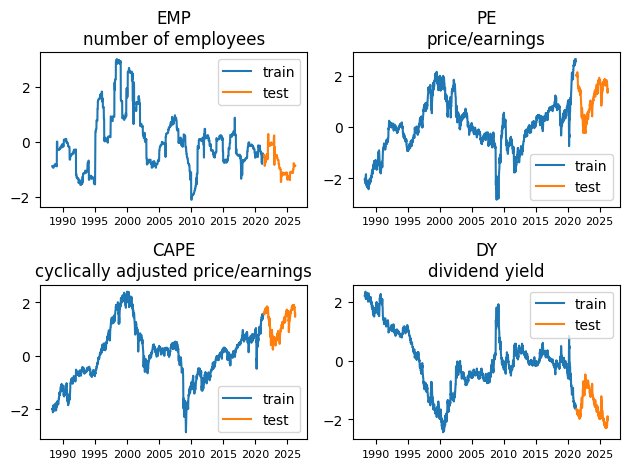

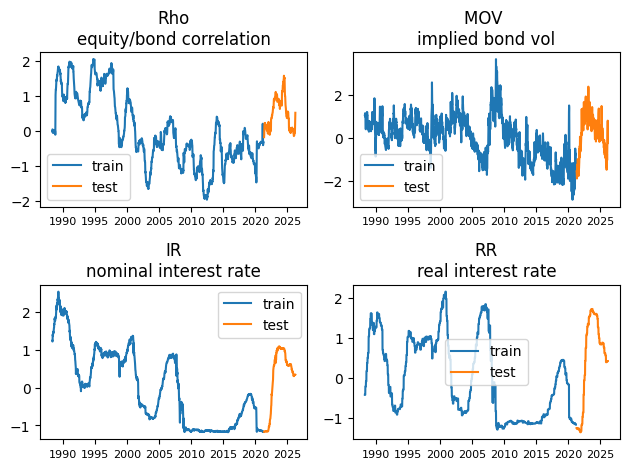

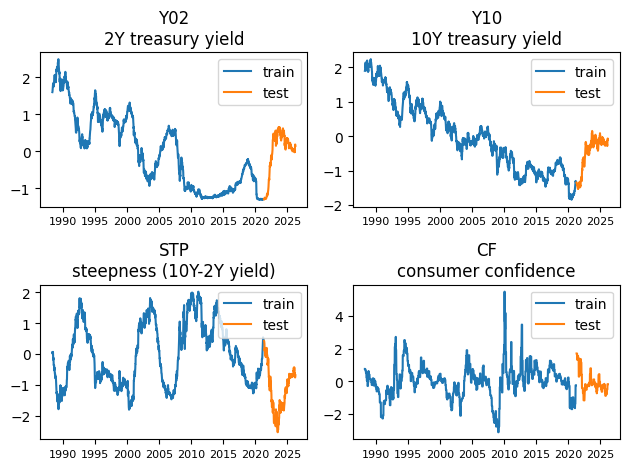

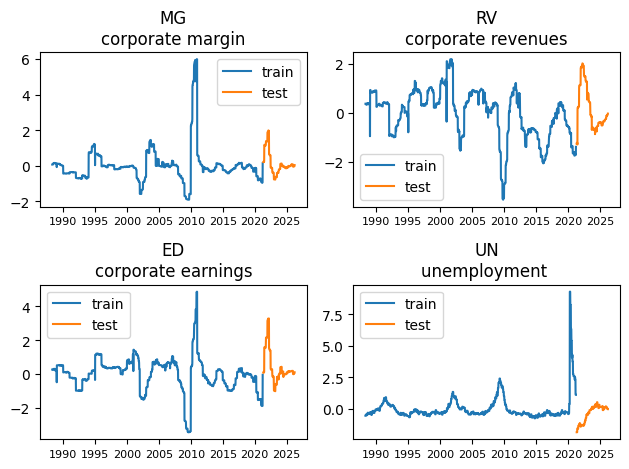

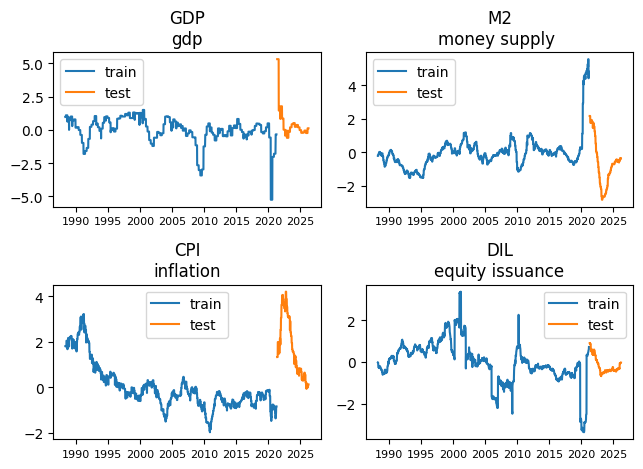

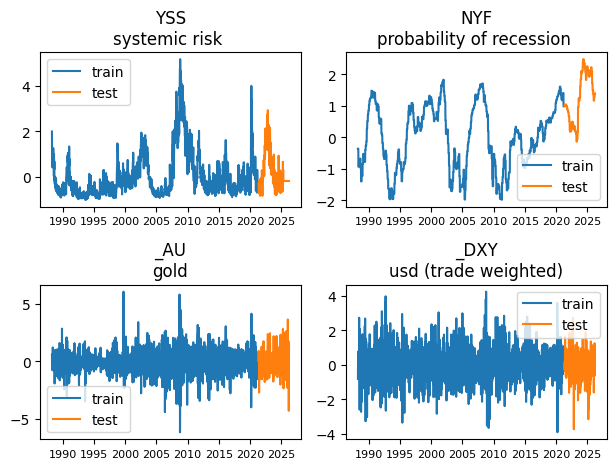

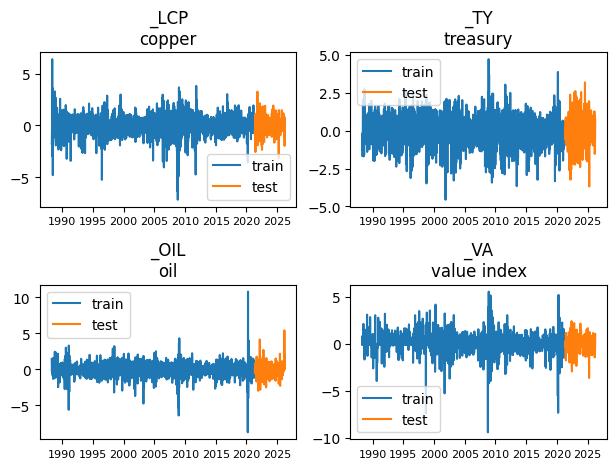

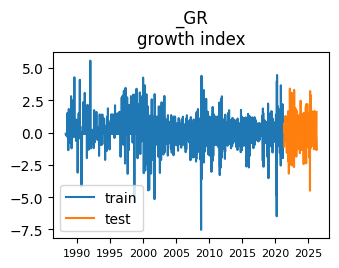

In [7]:
cols = list(X_train.columns)
for j, key in enumerate(cols):
    plt.subplot(2, 2, j % 4 + 1)
    plt.plot(X_train[key], label="train")
    plt.plot(X_test[key], label="test")
    plt.legend()
    desc = namings.loc[key, "Description"] if key in namings.index else ""
    plt.title(f"{key}\n{desc}")
    plt.xticks(fontsize=8)
    if j % 4 == 3 or j == len(cols) - 1:
        plt.tight_layout()
        plt.show()


In [8]:
def lagged_corr_matrix(X, Y, max_lag=5):
    X = X.copy()
    Y = Y.copy()

    common_idx = X.index.intersection(Y.index)
    X = X.loc[common_idx]
    Y = Y.loc[common_idx]

    lags = range(-max_lag, max_lag + 1)
    corr = pd.DataFrame(index=X.columns, columns=lags, dtype=float)

    for lag in lags:
        X_lagged = X.shift(lag)
        for col in X.columns:
            tmp = pd.concat([X_lagged[col], Y], axis=1).dropna()
            corr.loc[col, lag] = tmp.iloc[:, 0].corr(tmp.iloc[:, 1])

    return corr


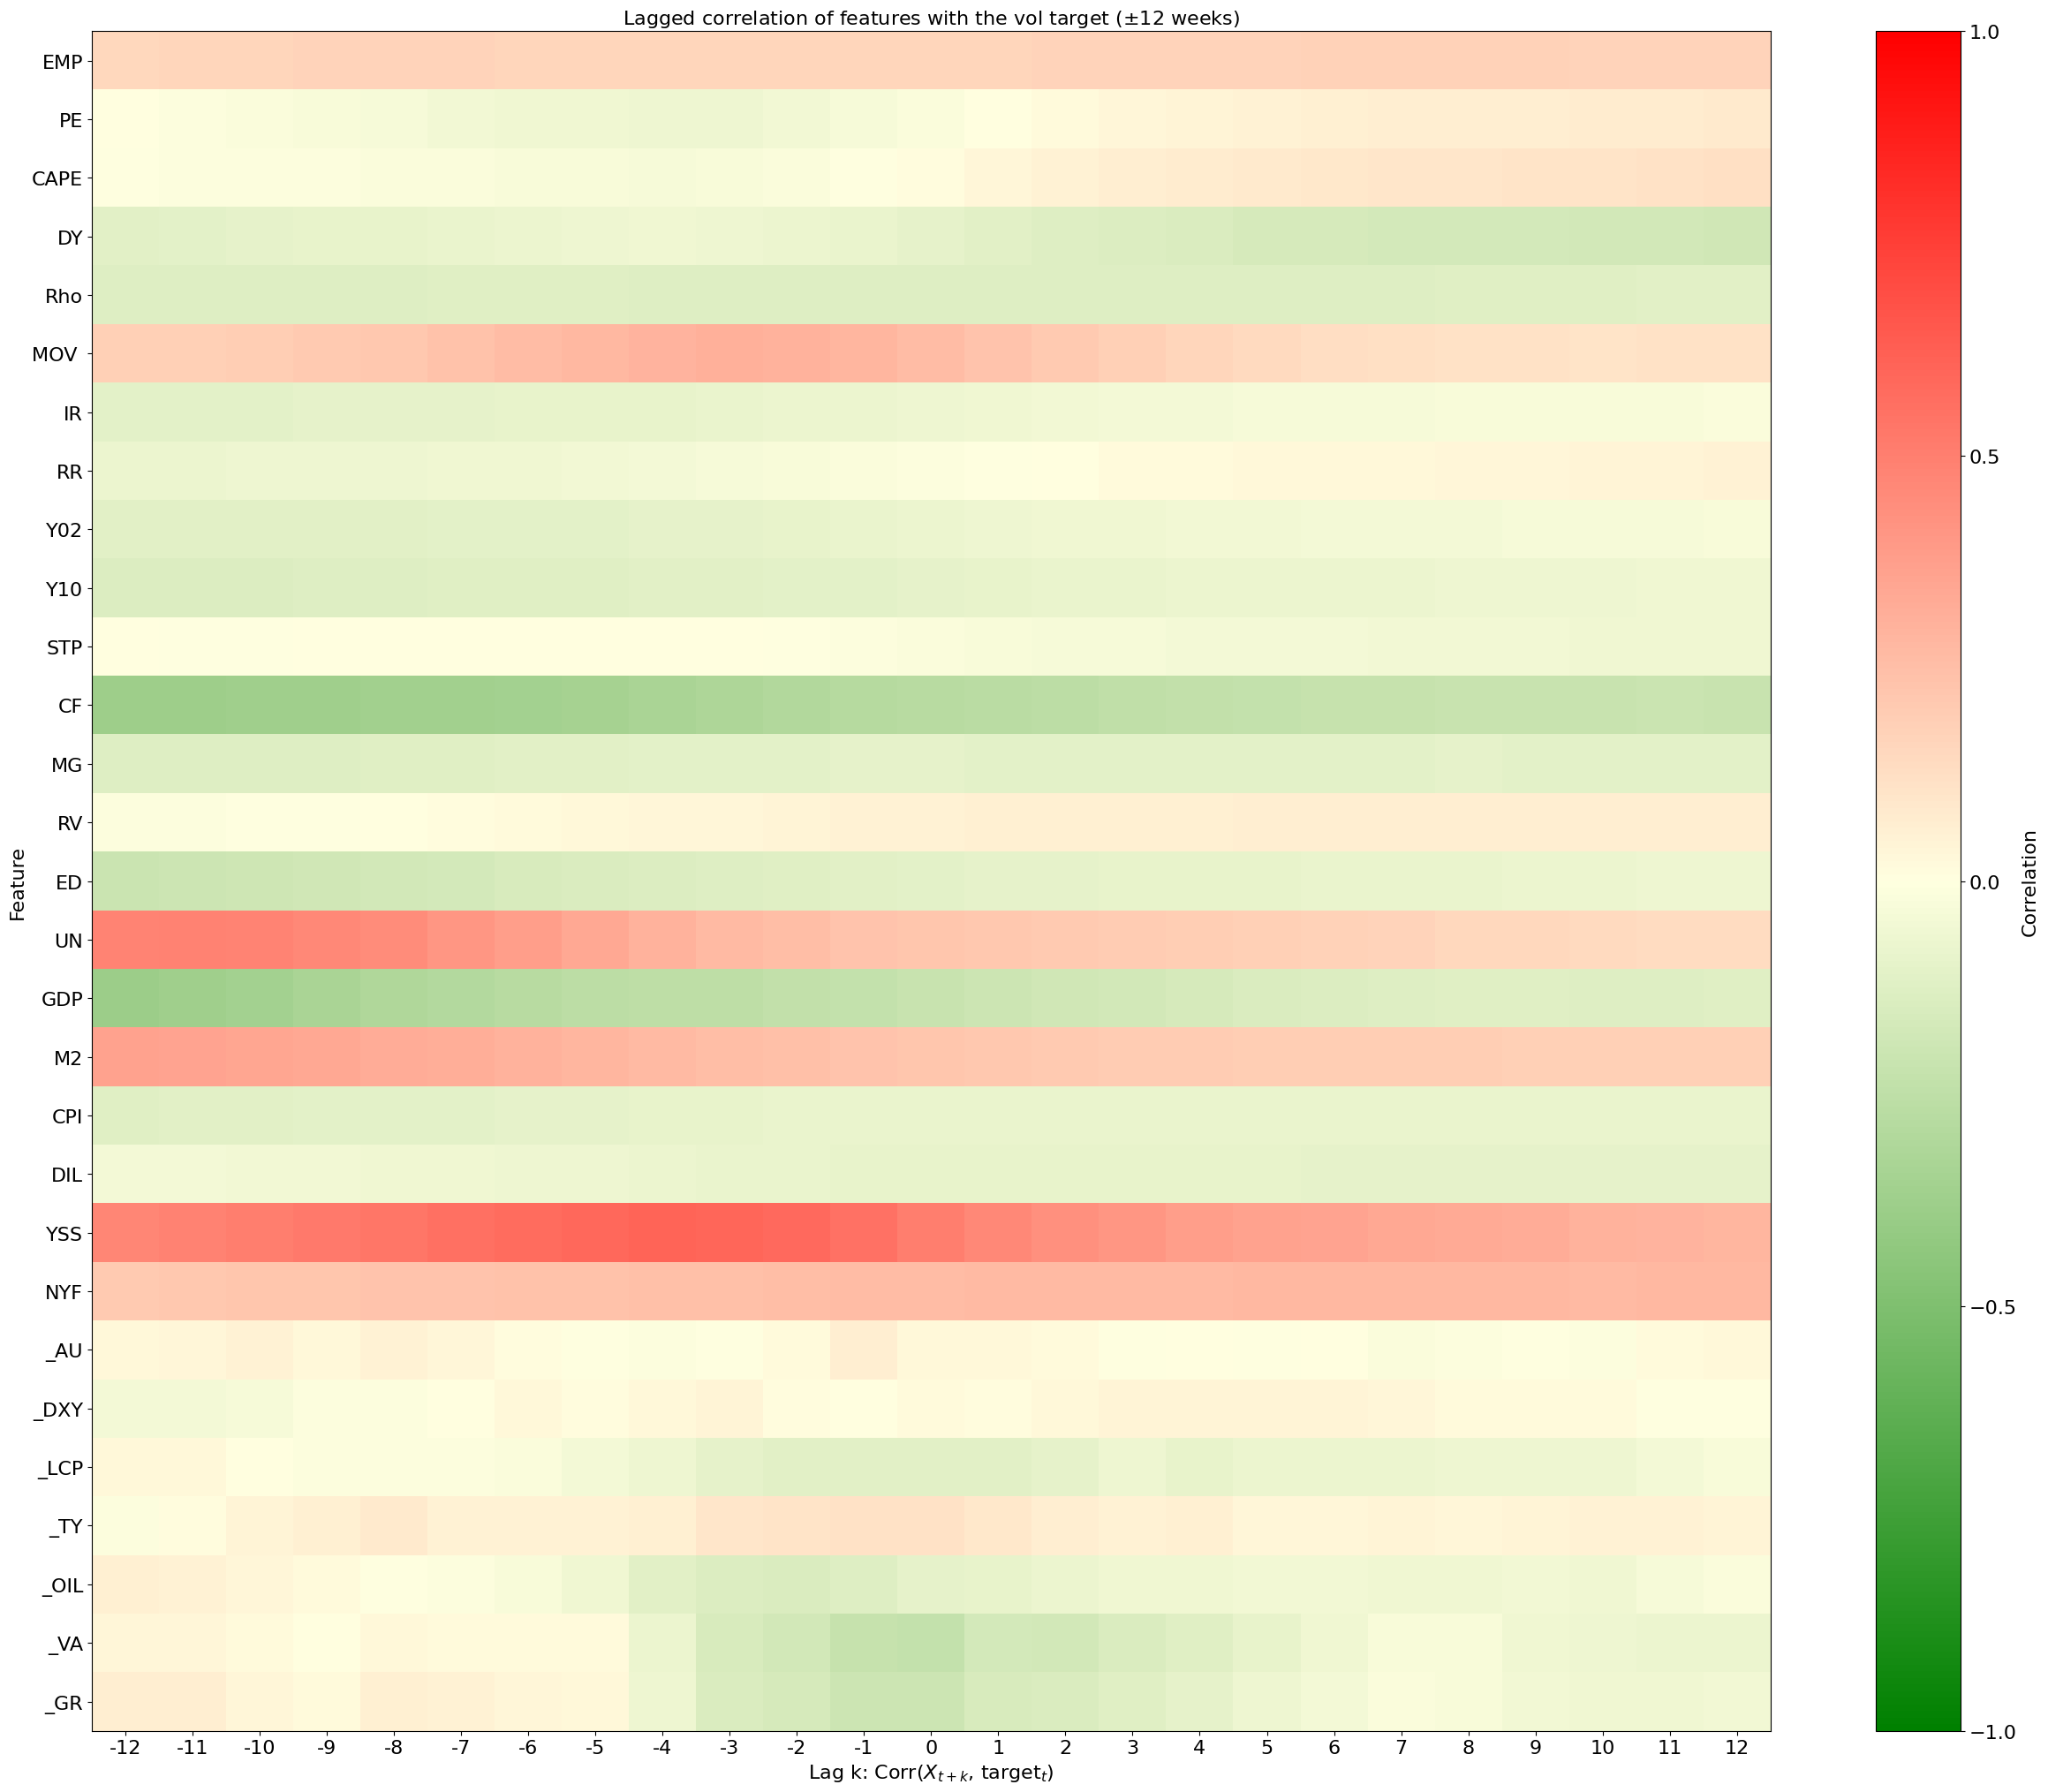

In [9]:
def plot_lagged_corr(X, Y, max_lag=5, figsize=None, annot=True, fontsize=16):
    corr = lagged_corr_matrix(X, Y, max_lag=max_lag)

    if figsize is None:
        figsize = (1.0 * (2 * max_lag + 1), 0.60 * len(corr) + 3)

    fig, ax = plt.subplots(figsize=figsize)

    cmap = LinearSegmentedColormap.from_list(
        "blue_green_red",
        [
            (0.00, "green"),
            (0.50, "lightyellow"),
            (1.00, "red"),
        ],
    )

    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    im = ax.imshow(corr.values, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")

    ax.set_xticks(np.arange(corr.shape[1]))
    ax.set_xticklabels(corr.columns, fontsize=fontsize)
    ax.set_yticks(np.arange(corr.shape[0]))
    ax.set_yticklabels(corr.index, fontsize=fontsize)

    ax.set_xlabel(f"Lag k: Corr($X_{{t+k}}$, target$_t$)", fontsize=fontsize)
    ax.set_ylabel("Feature", fontsize=fontsize)
    ax.set_title(rf"Lagged correlation of features with the vol target ($\pm${max_lag} weeks)", fontsize=fontsize)

    ax.tick_params(axis="both", labelsize=fontsize)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Correlation", fontsize=fontsize)
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    cbar.ax.tick_params(labelsize=fontsize)

    plt.tight_layout()
    plt.show()
    return corr


corr_train = plot_lagged_corr(X_train, Y_train, max_lag=12, fontsize=16)


## Model

A small RNN regresses the standardized forward vol target on the features. The
`hit` metric is the share of weeks where predicted and realized standardized vol
fall on the same side of their mean (an above or below average vol call), not a
market direction call.


In [10]:
train_data = pd.concat([X_train, Y_train], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
test_data = pd.concat([X_test, Y_test], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

X_train = train_data.drop(columns=[TARGET])
Y_train = train_data[TARGET]
X_test = test_data.drop(columns=[TARGET])
Y_test = test_data[TARGET]

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)
Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)

print(X_train_tensor.shape, X_test_tensor.shape)


torch.Size([1721, 29]) torch.Size([256, 29])


In [11]:
class RNNModel(torch.nn.Module):
    def __init__(self, n_features, hidden_size, seed=0):
        super().__init__()
        set_seed(seed)

        self.rnn = torch.nn.RNN(
            input_size=n_features,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.out = torch.nn.Linear(hidden_size, 1)

    def forward(self, X):
        h, _ = self.rnn(X)
        y = self.out(h[:, -1, :])
        return y


In [12]:
def tr(X_train, Y_train, X_test, Y_test, model, lr=1e-3, weight_decay=0.0, epochs=1000, seed=None, show_progress=True):
    if seed is not None:
        set_seed(seed)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = torch.nn.MSELoss()

    train_losses, test_losses = [], []
    train_hits, test_hits = [], []

    iterator = tqdm(range(epochs), desc="Training") if show_progress else range(epochs)

    for _ in iterator:
        model.train()
        opt.zero_grad()

        train_pred = model(X_train)
        train_loss = loss_fn(train_pred, Y_train)
        train_loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test)
            test_loss = loss_fn(test_pred, Y_test)
            # same side of the mean for predicted vs realized standardized vol
            train_hit = (torch.sign(train_pred) == torch.sign(Y_train)).float().mean()
            test_hit = (torch.sign(test_pred) == torch.sign(Y_test)).float().mean()

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        train_hits.append(train_hit.item())
        test_hits.append(test_hit.item())

        if show_progress:
            iterator.set_postfix({
                "train_loss": f"{train_loss.item():.4f}",
                "test_loss": f"{test_loss.item():.4f}",
                "train_hit": f"{train_hit.item():.3f}",
                "test_hit": f"{test_hit.item():.3f}",
            })

    return {
        "model": model,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_hits": train_hits,
        "test_hits": test_hits,
    }


In [13]:
n_features = X_train_tensor.shape[1]
hidden_size = 8

model = RNNModel(n_features, hidden_size)

X_train_rnn = X_train_tensor.unsqueeze(1)
X_test_rnn = X_test_tensor.unsqueeze(1)


In [14]:
hist = tr(
    X_train_rnn,
    Y_train_tensor,
    X_test_rnn,
    Y_test_tensor,
    model,
    lr=1e-3,
    weight_decay=1e-3,
    epochs=1000,
)


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

In [15]:
def get_predictions(model, X_train, Y_train, X_test, Y_test):
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train).detach().numpy().ravel()
        test_pred = model(X_test).detach().numpy().ravel()

    y_train = Y_train.detach().numpy().ravel()
    y_test = Y_test.detach().numpy().ravel()

    return train_pred, y_train, test_pred, y_test


def evaluate_model(model, X_train, Y_train, X_test, Y_test):
    train_pred, y_train, test_pred, y_test = get_predictions(model, X_train, Y_train, X_test, Y_test)

    residuals = y_test - test_pred
    train_mse = np.mean((y_train - train_pred) ** 2)
    test_mse = np.mean((y_test - test_pred) ** 2)
    train_hit = np.mean(np.sign(train_pred) == np.sign(y_train))
    test_hit = np.mean(np.sign(test_pred) == np.sign(y_test))
    test_corr = np.corrcoef(y_test, test_pred)[0, 1]

    return {
        "train_pred": train_pred,
        "y_train": y_train,
        "test_pred": test_pred,
        "y_test": y_test,
        "residuals": residuals,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "train_hit": train_hit,
        "test_hit": test_hit,
        "test_corr": test_corr,
    }


def run_seeds(seeds, X_train, Y_train, X_test, Y_test, n_features, hidden_size=8, lr=1e-3, weight_decay=1e-4, epochs=1000):
    runs = {}
    rows = []

    for seed in tqdm(seeds, desc="Seeds"):
        model = RNNModel(n_features, hidden_size, seed=seed)
        hist = tr(X_train, Y_train, X_test, Y_test, model, lr=lr, weight_decay=weight_decay, epochs=epochs, seed=seed, show_progress=False)
        diag = evaluate_model(hist["model"], X_train, Y_train, X_test, Y_test)
        runs[seed] = {"hist": hist, "diag": diag}
        rows.append({
            "seed": seed,
            "train_mse": diag["train_mse"],
            "test_mse": diag["test_mse"],
            "train_hit": diag["train_hit"],
            "test_hit": diag["test_hit"],
            "test_corr": diag["test_corr"],
        })

    return runs, pd.DataFrame(rows).set_index("seed")


In [16]:
def plot_training_diagnostics(hist, model, X_train, Y_train, X_test, Y_test):
    train_pred, y_train, test_pred, y_test = get_predictions(model, X_train, Y_train, X_test, Y_test)

    plt.figure(figsize=(12, 6))
    plt.plot(hist["train_losses"], label="Train loss")
    plt.plot(hist["test_losses"], label="Test loss")
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("MSE loss", fontsize=14)
    plt.title("Training and test loss", fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(hist["train_hits"], label="Train hit rate")
    plt.plot(hist["test_hits"], label="Test hit rate")
    plt.axhline(0.5, linestyle="--", label="Random baseline")
    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Hit rate", fontsize=14)
    plt.title("Above or below average vol hit rate", fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 6))
    plt.plot(y_test, label="Actual forward vol")
    plt.plot(test_pred, label="Predicted forward vol")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Test observation", fontsize=14)
    plt.ylabel("Standardized forward vol", fontsize=14)
    plt.title("Test predictions vs actual", fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, test_pred, alpha=0.7)
    lo = min(y_test.min(), test_pred.min())
    hi = max(y_test.max(), test_pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("Actual forward vol", fontsize=14)
    plt.ylabel("Predicted forward vol", fontsize=14)
    plt.title("Predicted vs actual", fontsize=16)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    residuals = y_test - test_pred

    plt.figure(figsize=(14, 6))
    plt.plot(residuals, label="Residual")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Test observation", fontsize=14)
    plt.ylabel("Actual - predicted", fontsize=14)
    plt.title("Test residuals", fontsize=16)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    train_mse = np.mean((y_train - train_pred) ** 2)
    test_mse = np.mean((y_test - test_pred) ** 2)
    train_hit = np.mean(np.sign(train_pred) == np.sign(y_train))
    test_hit = np.mean(np.sign(test_pred) == np.sign(y_test))
    test_corr = np.corrcoef(y_test, test_pred)[0, 1]

    print("Train MSE:", train_mse)
    print("Test MSE :", test_mse)
    print("Train hit:", train_hit)
    print("Test hit :", test_hit)
    print("Test corr:", test_corr)

    return {
        "train_pred": train_pred,
        "y_train": y_train,
        "test_pred": test_pred,
        "y_test": y_test,
        "residuals": residuals,
        "train_mse": train_mse,
        "test_mse": test_mse,
        "train_hit": train_hit,
        "test_hit": test_hit,
        "test_corr": test_corr,
    }


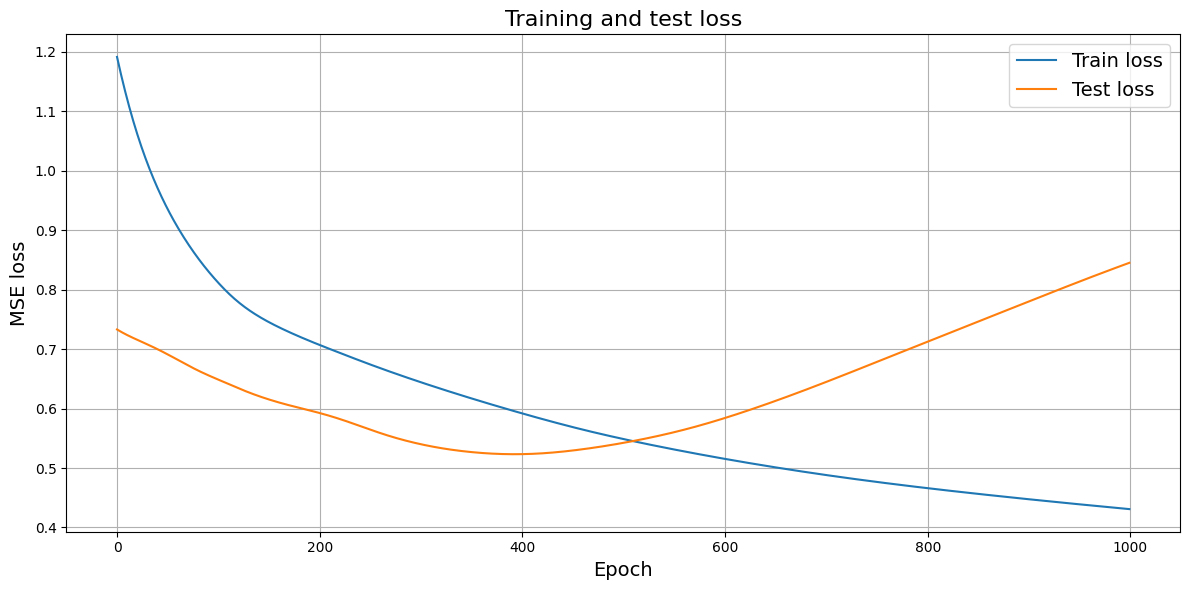

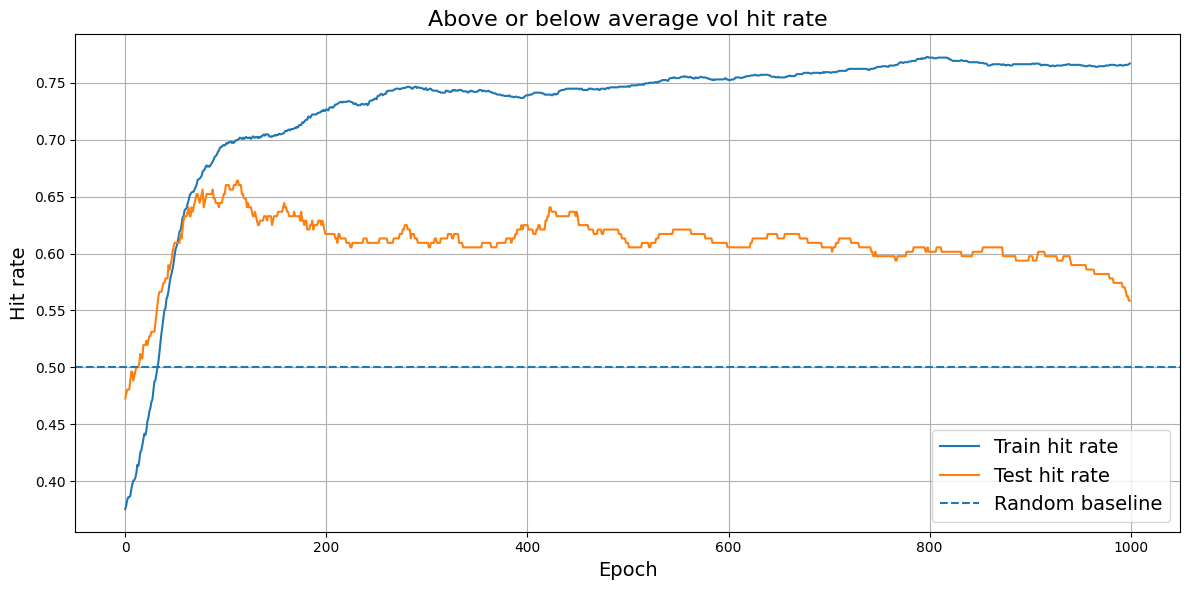

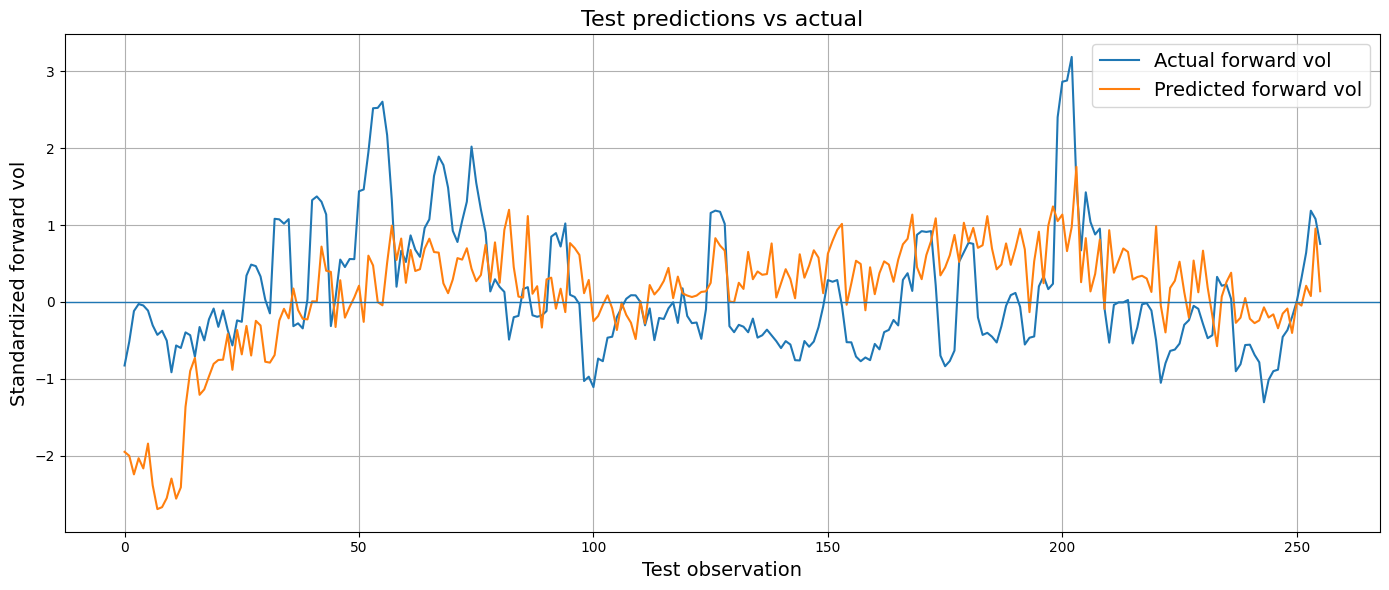

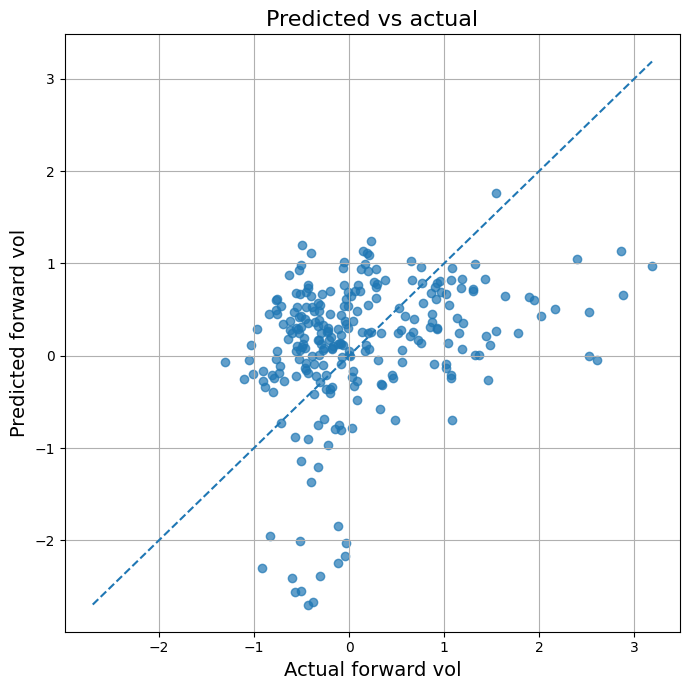

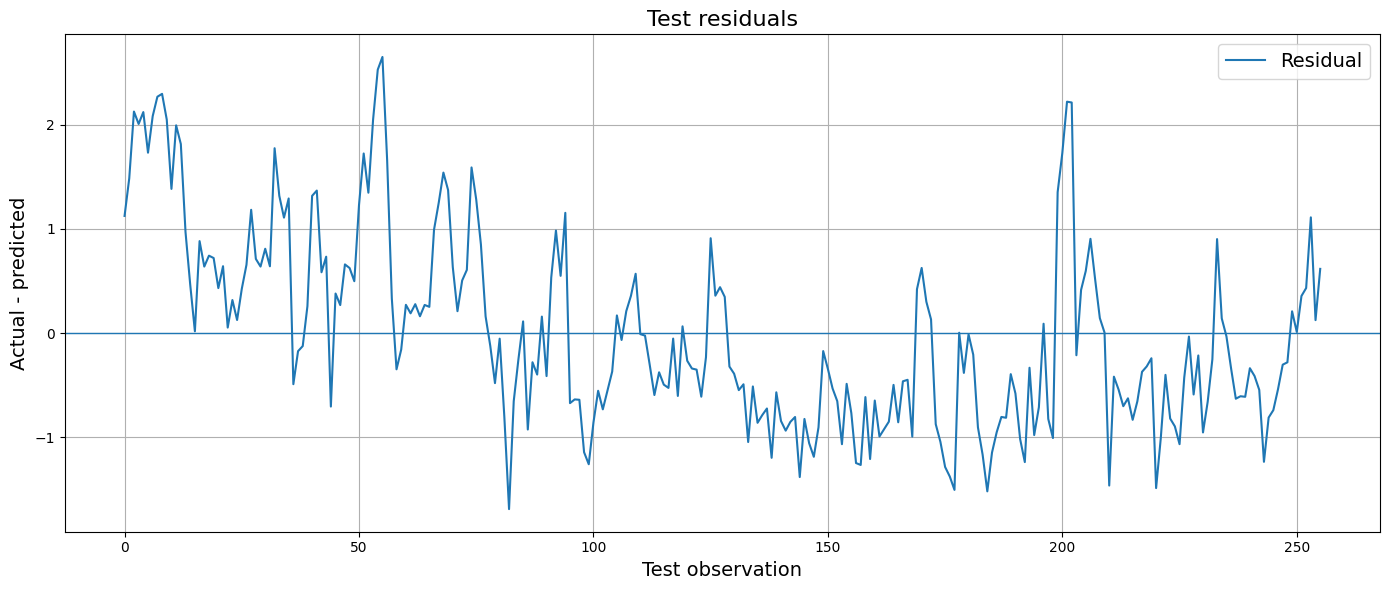

Train MSE: 0.43071926
Test MSE : 0.84519243
Train hit: 0.7669959325973271
Test hit : 0.55859375
Test corr: 0.2956653675459988


In [17]:
diag = plot_training_diagnostics(
    hist,
    hist["model"],
    X_train_rnn,
    Y_train_tensor,
    X_test_rnn,
    Y_test_tensor,
)


In [18]:
seed_runs, seed_summary = run_seeds(
    SEEDS,
    X_train_rnn,
    Y_train_tensor,
    X_test_rnn,
    Y_test_tensor,
    n_features,
    hidden_size=hidden_size,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=1000,
)

seed_summary


Seeds:   0%|          | 0/50 [00:00<?, ?it/s]

,train_mse,test_mse,train_hit,test_hit,test_corr
seed,,,,,
8663,0.448093,1.104551,0.764672,0.523438,0.226590
3442,0.382860,0.710198,0.770482,0.718750,0.477281
7974,0.437526,0.959623,0.760604,0.488281,0.113555
2342,0.395337,1.099415,0.771644,0.496094,0.193034
1694,0.386409,0.805071,0.764091,0.636719,0.461025
4498,0.405365,0.924368,0.753632,0.546875,0.431001
2045,0.439421,0.951584,0.762929,0.605469,0.350683
1419,0.448619,1.024764,0.762347,0.554688,0.366272
7884,0.474323,0.850298,0.766996,0.519531,0.440240


In [19]:
seed_summary.describe()


,train_mse,test_mse,train_hit,test_hit,test_corr
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.415289,1.073551,0.764474,0.575000,0.294804
std,0.025239,0.318897,0.006997,0.064823,0.124985
min,0.363070,0.671257,0.742592,0.449219,-0.003496
25%,0.396200,0.847786,0.759733,0.523438,0.224566
50%,0.413423,0.989627,0.764962,0.564453,0.290927
75%,0.431812,1.227991,0.768739,0.626953,0.380212
max,0.476063,2.281208,0.781522,0.718750,0.486248


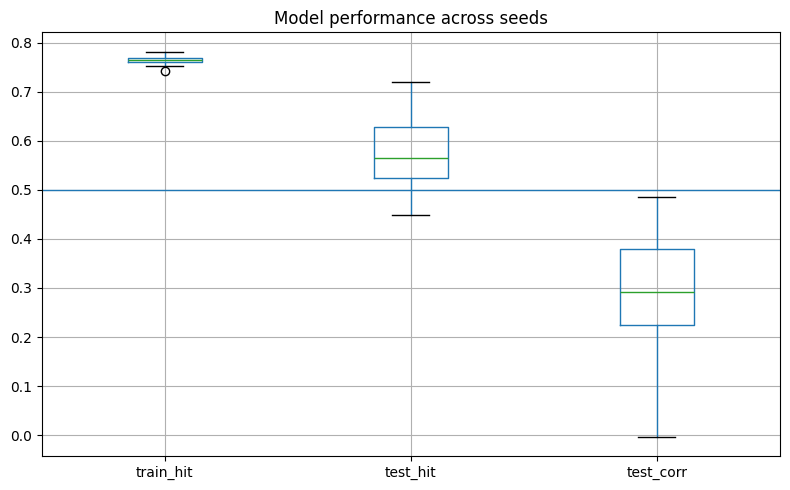

In [20]:
seed_summary[["train_hit", "test_hit", "test_corr"]].boxplot(figsize=(8, 5))
plt.axhline(0.5, linewidth=1)
plt.title("Model performance across seeds")
plt.tight_layout()
plt.show()


In [21]:
check = pd.DataFrame({
    "pred_vol_std": diag["test_pred"],
    "true_vol_std": Y_test.values,
    "raw_mkt": df.loc[X_test.index, "_MKT"],
}, index=X_test.index)

check["mkt_ret"] = check["raw_mkt"].pct_change()
check["mkt_ret_next"] = check["raw_mkt"].pct_change().shift(-1)

# pred vs true vol shows model skill; pred vol vs returns shows the leverage effect
check[["pred_vol_std", "true_vol_std", "mkt_ret", "mkt_ret_next"]].corr()


,pred_vol_std,true_vol_std,mkt_ret,mkt_ret_next
pred_vol_std,1.000000,0.295665,-0.203960,0.064148
true_vol_std,0.295665,1.000000,-0.253832,-0.159938
mkt_ret,-0.203960,-0.253832,1.000000,-0.100879
mkt_ret_next,0.064148,-0.159938,-0.100879,1.000000


## Strategy

Exposure is driven by the predicted forward vol `VOL{WINDOW}w_MKT`. High predicted
vol reduces exposure, low predicted vol adds exposure. Trades and P&L are on the
raw `_MKT` series. The backtest is self financing in index points.

`make_dynamic_exposure` steps exposure by `step` when standardized predicted vol
crosses the threshold band. `make_vol_target_exposure` is an alternative that
sizes inversely to the predicted vol level.


In [22]:
def make_dynamic_exposure(pred, threshold=1.0, step=0.1, base=1.0, min_w=0.0, max_w=2.0):
    '''
    pred: standardized predicted forward vol.
    pred >  +threshold (high vol)  -> step exposure down.
    pred <  -threshold (low vol)   -> step exposure up.
    '''
    pred = np.asarray(pred).ravel()
    w = np.empty_like(pred, dtype=float)
    current_w = base

    for i, p in enumerate(pred):
        if p > threshold:
            current_w -= step
        elif p < -threshold:
            current_w += step
        current_w = np.clip(current_w, min_w, max_w)
        w[i] = current_w

    return w


def make_vol_target_exposure(pred, params, target_vol=None, min_w=0.0, max_w=2.0):
    '''
    Alternative sizing: undo standardization to get predicted vol in real units,
    then w = target_vol / predicted_vol. If target_vol is None use the median
    predicted vol so average exposure is near 1.
    '''
    pred_vol = np.asarray(pred).ravel() * params["Y_std"] + params["Y_mean"]
    pred_vol = np.clip(pred_vol, 1e-8, None)
    if target_vol is None:
        target_vol = float(np.median(pred_vol))
    return np.clip(target_vol / pred_vol, min_w, max_w)


In [23]:
def backtest_dynamic_exposure_self_financing(pred, raw_mkt, threshold=1.0, step=0.1, base=1.0, min_w=0.0, max_w=2.0, w=None):
    pred = np.asarray(pred).ravel()
    raw_mkt = pd.Series(raw_mkt).dropna().iloc[-len(pred):]

    if w is None:
        w = make_dynamic_exposure(pred, threshold=threshold, step=step, base=base, min_w=min_w, max_w=max_w)

    bt = pd.DataFrame(index=raw_mkt.index)
    bt["S"] = raw_mkt.values          # traded series = raw _MKT
    bt["pred_vol"] = pred             # standardized predicted forward vol
    bt["w"] = w

    bt["dw"] = bt["w"].diff()
    bt.loc[bt.index[0], "dw"] = bt["w"].iloc[0] - base   # fixed: no chained assignment

    bt["trade_cashflow"] = -bt["dw"] * bt["S"]
    bt["cash"] = bt["trade_cashflow"].cumsum()
    bt["position_value"] = bt["w"] * bt["S"]

    initial_position_value = base * bt["S"].iloc[0]

    bt["strategy_value"] = bt["cash"] + bt["position_value"]
    bt["strategy_pnl"] = bt["strategy_value"] - initial_position_value

    bt["buy_hold_value"] = base * bt["S"]
    bt["buy_hold_pnl"] = bt["buy_hold_value"] - initial_position_value

    bt["active_pnl"] = bt["strategy_pnl"] - bt["buy_hold_pnl"]

    return bt


In [24]:
raw_mkt_test = df.loc[X_test.index, "_MKT"]
raw_mkt_train = df.loc[X_train.index, "_MKT"]

bt_test = backtest_dynamic_exposure_self_financing(
    pred=diag["test_pred"],
    raw_mkt=raw_mkt_test,
    threshold=1.0,
    step=0.1,
    base=1.0,
    min_w=0.0,
    max_w=2.0,
)

bt_train = backtest_dynamic_exposure_self_financing(
    pred=diag["train_pred"],
    raw_mkt=raw_mkt_train,
    threshold=1.0,
    step=0.1,
    base=1.0,
    min_w=0.0,
    max_w=2.0,
)


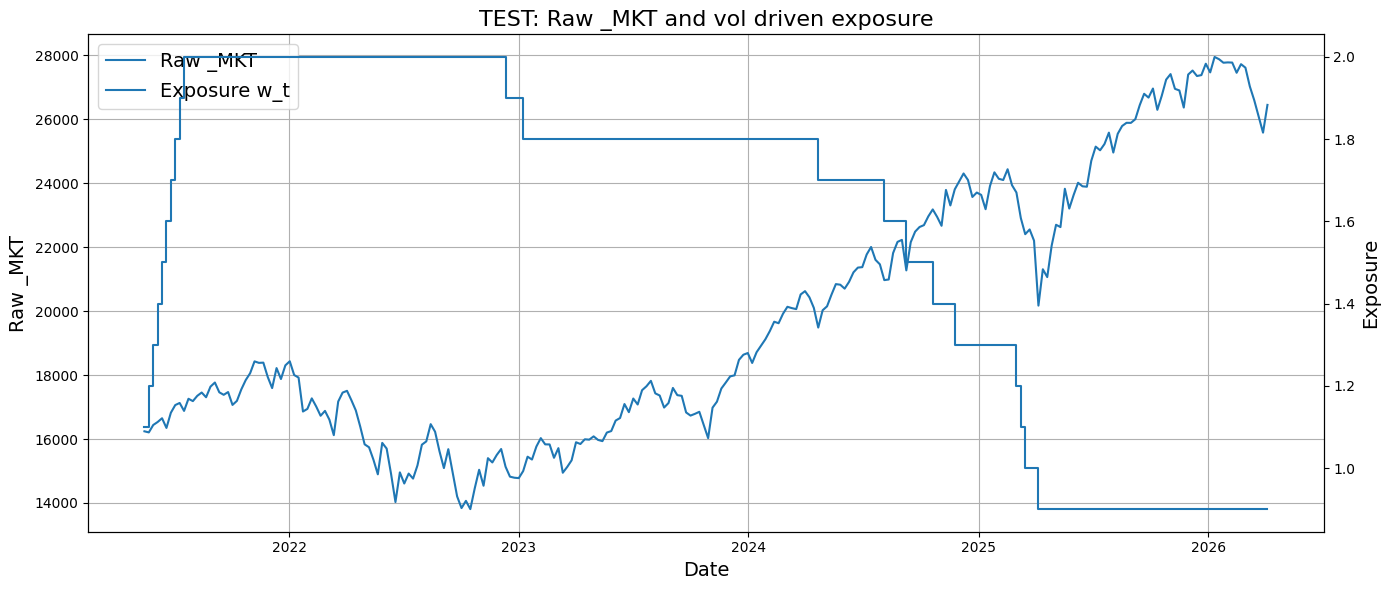

In [25]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_test.index, bt_test["S"], label="Raw _MKT")
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw _MKT", fontsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_test.index, bt_test["w"], where="post", label="Exposure w_t")
ax2.set_ylabel("Exposure", fontsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title("TEST: Raw _MKT and vol driven exposure", fontsize=16)
plt.tight_layout()
plt.show()


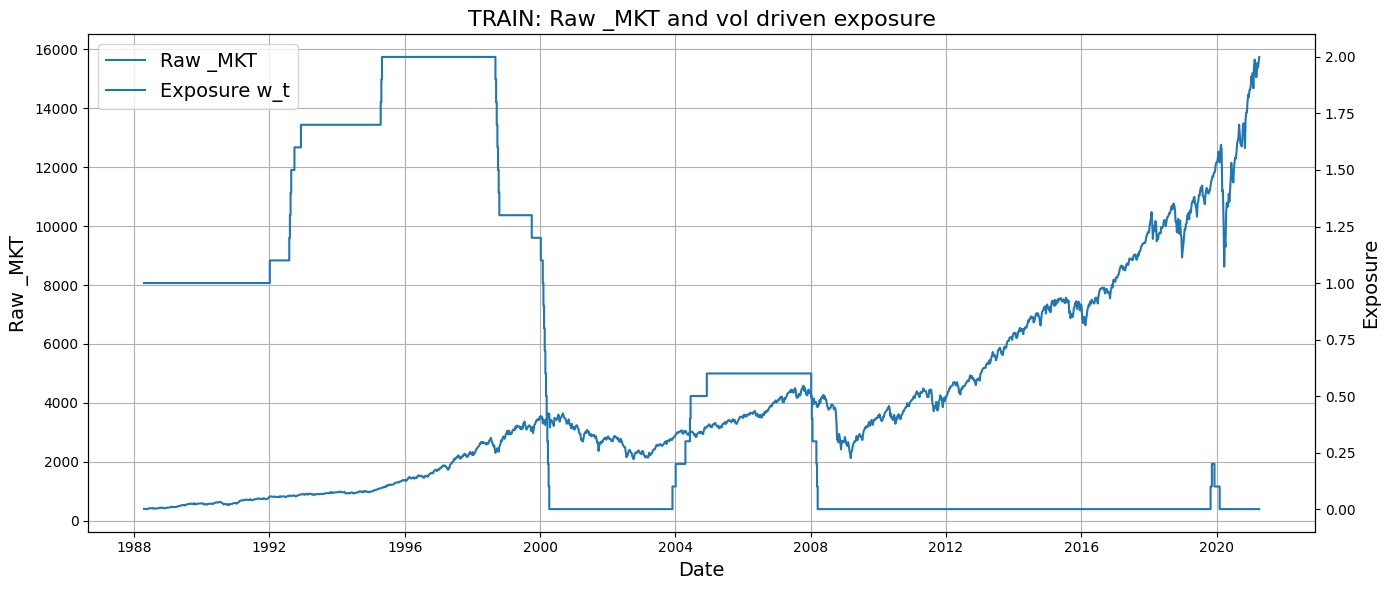

In [26]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_train.index, bt_train["S"], label="Raw _MKT")
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw _MKT", fontsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_train.index, bt_train["w"], where="post", label="Exposure w_t")
ax2.set_ylabel("Exposure", fontsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title("TRAIN: Raw _MKT and vol driven exposure", fontsize=16)
plt.tight_layout()
plt.show()


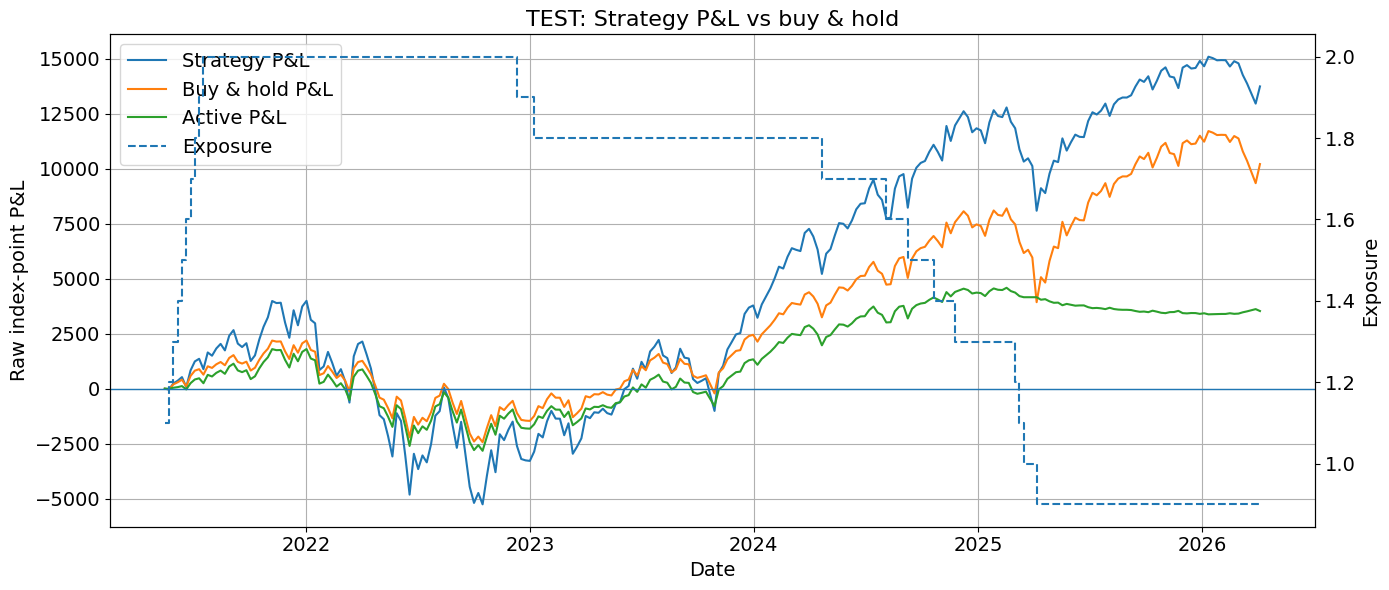

In [27]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_test.index, bt_test["strategy_pnl"], label="Strategy P&L")
ax1.plot(bt_test.index, bt_test["buy_hold_pnl"], label="Buy & hold P&L")
ax1.plot(bt_test.index, bt_test["active_pnl"], label="Active P&L")

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw index-point P&L", fontsize=14)
ax1.tick_params(axis="both", labelsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_test.index, bt_test["w"], where="post", label="Exposure", linestyle="--")
ax2.set_ylabel("Exposure", fontsize=14)
ax2.tick_params(axis="both", labelsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title("TEST: Strategy P&L vs buy & hold", fontsize=16)
plt.tight_layout()
plt.show()


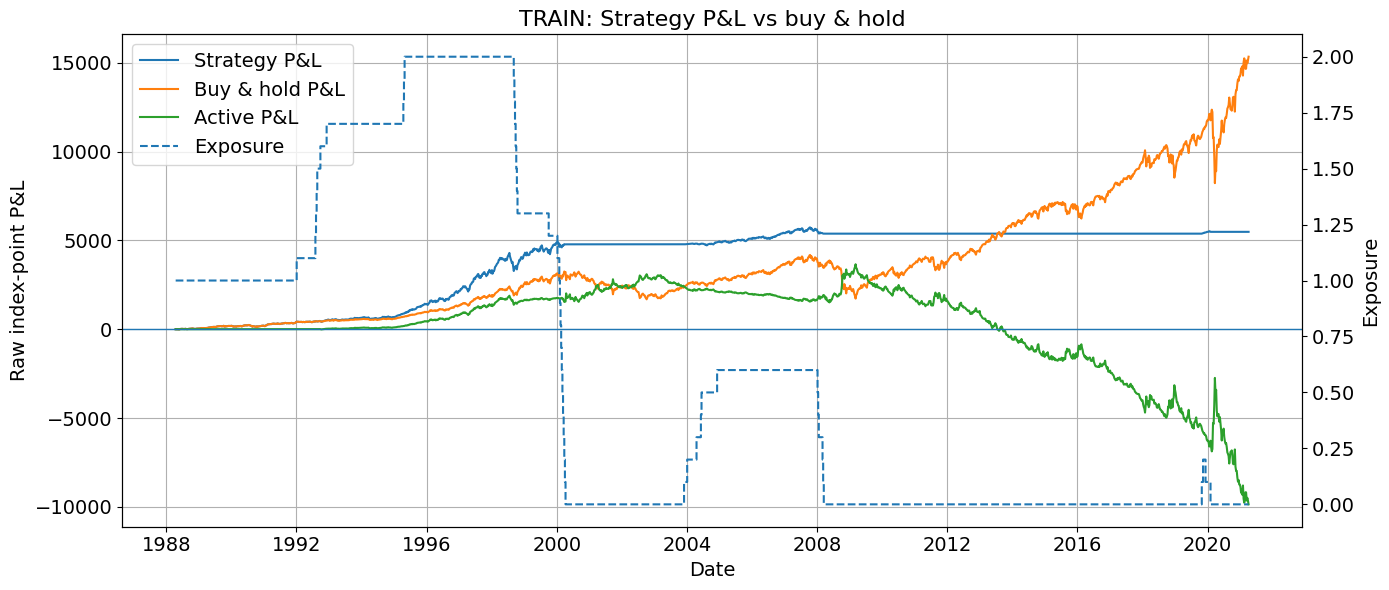

In [28]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_train.index, bt_train["strategy_pnl"], label="Strategy P&L")
ax1.plot(bt_train.index, bt_train["buy_hold_pnl"], label="Buy & hold P&L")
ax1.plot(bt_train.index, bt_train["active_pnl"], label="Active P&L")

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw index-point P&L", fontsize=14)
ax1.tick_params(axis="both", labelsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_train.index, bt_train["w"], where="post", label="Exposure", linestyle="--")
ax2.set_ylabel("Exposure", fontsize=14)
ax2.tick_params(axis="both", labelsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title("TRAIN: Strategy P&L vs buy & hold", fontsize=16)
plt.tight_layout()
plt.show()


## Information ratio

Returns are built on `_MKT`. Strategy return uses the previous week exposure, so
there is no look ahead. Active return is strategy minus market.


In [29]:
def add_ir_returns(bt):
    bt = bt.copy()

    bt["mkt_ret"] = bt["S"].pct_change()
    bt["strategy_ret"] = bt["w"].shift(1) * bt["mkt_ret"]
    bt["active_ret"] = bt["strategy_ret"] - bt["mkt_ret"]

    bt[["mkt_ret", "strategy_ret", "active_ret"]] = (
        bt[["mkt_ret", "strategy_ret", "active_ret"]].replace([np.inf, -np.inf], np.nan)
    )

    return bt


def IR(bt, periods_per_year=52):
    tmp = bt["active_ret"].dropna()
    if tmp.std(ddof=1) == 0:
        return np.nan
    return tmp.mean() / tmp.std(ddof=1) * np.sqrt(periods_per_year)


In [30]:
bt_train_ir = add_ir_returns(bt_train)
bt_test_ir = add_ir_returns(bt_test)

bt_all_ir = pd.concat([bt_train_ir, bt_test_ir]).sort_index()


In [31]:
ir_summary = pd.Series({
    "train_IR": IR(bt_train_ir),
    "test_IR": IR(bt_test_ir),
    "all_IR": IR(bt_all_ir),
})

ir_summary


train_IR   -0.117385
test_IR     0.357288
all_IR     -0.062360
dtype: float64

In [32]:
bt_train_tmp = bt_train_ir.copy()
bt_test_tmp = bt_test_ir.copy()

bt_train_tmp["sample"] = "train"
bt_test_tmp["sample"] = "test"

bt_all_tmp = pd.concat([bt_train_tmp, bt_test_tmp]).sort_index()

yearly_IR = bt_all_tmp.groupby([bt_all_tmp.index.year, "sample"]).apply(IR)
yearly_IR.name = "IR"

yearly_IR


Date  sample
1988  train          NaN
1989  train          NaN
1990  train          NaN
1991  train          NaN
1992  train     1.594831
1993  train     0.766572
1994  train     0.320478
1995  train     4.433044
1996  train     1.989754
1997  train     1.747936
1998  train     0.938851
1999  train     0.908883
2000  train     0.225874
2001  train     0.406352
2002  train     1.164615
2003  train    -1.786549
2004  train    -1.206879
2005  train    -0.919449
2006  train    -1.411998
2007  train    -0.623704
2008  train     1.188025
2009  train    -1.256584
2010  train    -0.908288
2011  train    -0.220083
2012  train    -1.097564
2013  train    -2.903567
2014  train    -1.352053
2015  train    -0.070259
2016  train    -0.934994
2017  train    -3.194057
2018  train     0.266737
2019  train    -2.609022
2020  train    -0.732558
2021  test      1.508864
      train    -1.714207
2022  test     -0.774977
2023  test      1.740918
2024  test      1.954476
2025  test     -2.005338
2026  test  

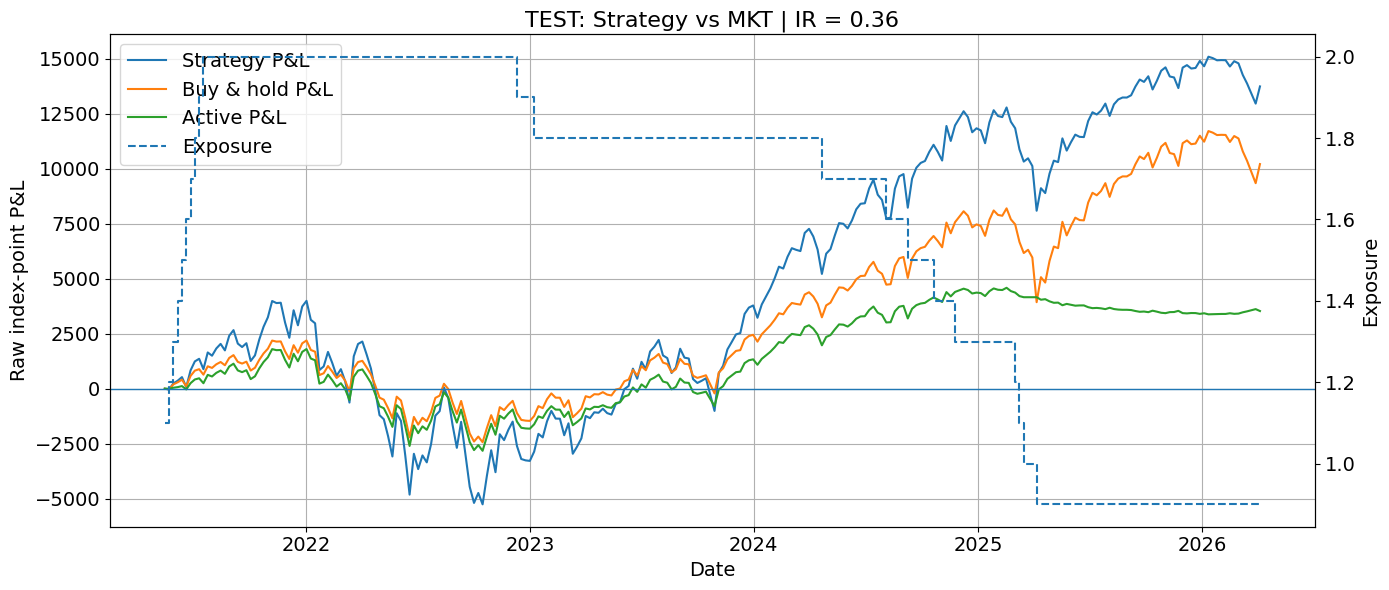

In [33]:
test_ir = IR(bt_test_ir)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(bt_test_ir.index, bt_test_ir["strategy_pnl"], label="Strategy P&L")
ax1.plot(bt_test_ir.index, bt_test_ir["buy_hold_pnl"], label="Buy & hold P&L")
ax1.plot(bt_test_ir.index, bt_test_ir["active_pnl"], label="Active P&L")

ax1.axhline(0, linewidth=1)
ax1.set_xlabel("Date", fontsize=14)
ax1.set_ylabel("Raw index-point P&L", fontsize=14)
ax1.tick_params(axis="both", labelsize=14)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.step(bt_test_ir.index, bt_test_ir["w"], where="post", label="Exposure", linestyle="--")
ax2.set_ylabel("Exposure", fontsize=14)
ax2.tick_params(axis="both", labelsize=14)

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, fontsize=14, loc="best")

plt.title(f"TEST: Strategy vs MKT | IR = {test_ir:.2f}", fontsize=16)
plt.tight_layout()
plt.show()


In [34]:
pd.Series({
    "n_test_obs": len(bt_test_ir),
    "mean_active_ret": bt_test_ir["active_ret"].mean(),
    "std_active_ret": bt_test_ir["active_ret"].std(),
    "IR": IR(bt_test_ir),
    "final_active_pnl": bt_test_ir["active_pnl"].iloc[-1],
    "avg_exposure": bt_test_ir["w"].mean(),
    "min_exposure": bt_test_ir["w"].min(),
    "max_exposure": bt_test_ir["w"].max(),
})


n_test_obs           256.000000
mean_active_ret        0.000891
std_active_ret         0.017985
IR                     0.357288
final_active_pnl    3528.274000
avg_exposure           1.595312
min_exposure           0.900000
max_exposure           2.000000
dtype: float64

In [35]:
bt_test_ir[["active_ret", "active_pnl"]].tail()


,active_ret,active_pnl
Date,,
2026-03-08,0.002124,3470.518
2026-03-15,0.001595,3513.630
2026-03-22,0.001899,3564.141
2026-03-29,0.001952,3615.061
2026-04-05,-0.003393,3528.274


## Benchmarks and seed robustness

Compare the strategy against the market at unit exposure and against a constant
average exposure version of itself, then repeat across seeds.


In [36]:
def IR_series(x, periods_per_year=52):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    vol = x.std(ddof=1)
    if vol == 0 or np.isnan(vol):
        return np.nan
    return x.mean() / vol * np.sqrt(periods_per_year)


def add_constant_exposure_benchmark(bt):
    bt = bt.copy()

    w_bar = bt["w"].mean()

    bt["mkt_ret"] = bt["S"].pct_change()
    bt["strategy_ret"] = bt["w"].shift(1) * bt["mkt_ret"]
    bt["const_w_ret"] = w_bar * bt["mkt_ret"]

    bt["active_ret_vs_MKT"] = bt["strategy_ret"] - bt["mkt_ret"]
    bt["active_ret_vs_const_w"] = bt["strategy_ret"] - bt["const_w_ret"]

    return bt.replace([np.inf, -np.inf], np.nan)


In [37]:
bt_test_check = add_constant_exposure_benchmark(bt_test)

pd.Series({
    "IR_vs_MKT_1x": IR_series(bt_test_check["active_ret_vs_MKT"]),
    "IR_vs_const_avg_exposure": IR_series(bt_test_check["active_ret_vs_const_w"]),
    "avg_exposure": bt_test_check["w"].mean(),
})


IR_vs_MKT_1x                0.357288
IR_vs_const_avg_exposure   -0.292808
avg_exposure                1.595312
dtype: float64

In [38]:
def extract_test_pred(run):
    if isinstance(run, dict):
        for k in ["test_pred", "pred", "pred_test", "y_pred_test"]:
            if k in run:
                return np.asarray(run[k]).ravel()
        if "diag" in run:
            diag = run["diag"]
            for k in ["test_pred", "pred", "pred_test", "y_pred_test"]:
                if k in diag:
                    return np.asarray(diag[k]).ravel()
    return np.asarray(run).ravel()


raw_mkt_test = df.loc[X_test.index, "_MKT"]

seed_compare = []

if isinstance(seed_runs, dict):
    run_iter = list(seed_runs.items())
else:
    run_iter = list(enumerate(seed_runs))

for seed_key, run in run_iter:
    pred = extract_test_pred(run)

    if len(pred) != len(raw_mkt_test):
        pred = pred[-len(raw_mkt_test):]

    bt_seed = backtest_dynamic_exposure_self_financing(
        pred=pred,
        raw_mkt=raw_mkt_test,
        threshold=1.0,
        step=0.1,
        base=1.0,
        min_w=0.0,
        max_w=2.0,
    )

    bt_seed = add_constant_exposure_benchmark(bt_seed)

    seed_compare.append({
        "seed_key": seed_key,
        "test_IR_vs_MKT_1x": IR_series(bt_seed["active_ret_vs_MKT"]),
        "test_IR_vs_const_avg_exposure": IR_series(bt_seed["active_ret_vs_const_w"]),
        "avg_exposure": bt_seed["w"].mean(),
        "min_exposure": bt_seed["w"].min(),
        "max_exposure": bt_seed["w"].max(),
        "final_active_pnl_vs_MKT": bt_seed["active_pnl"].iloc[-1],
    })

seed_compare = pd.DataFrame(seed_compare)

seed_summary_fixed = seed_summary.copy().reset_index(drop=False)

if len(seed_summary_fixed) == len(seed_compare):
    seed_results = pd.concat(
        [seed_summary_fixed.reset_index(drop=True), seed_compare.reset_index(drop=True)],
        axis=1,
    )
else:
    seed_results = seed_compare.copy()

display(seed_results)

cols = [
    "test_mse",
    "test_hit",
    "test_corr",
    "test_IR_vs_MKT_1x",
    "test_IR_vs_const_avg_exposure",
    "avg_exposure",
    "min_exposure",
    "max_exposure",
    "final_active_pnl_vs_MKT",
]

cols = [c for c in cols if c in seed_results.columns]

display(seed_results[cols].describe())


,seed,train_mse,test_mse,train_hit,test_hit,test_corr,seed_key,test_IR_vs_MKT_1x,test_IR_vs_const_avg_exposure,avg_exposure,min_exposure,max_exposure,final_active_pnl_vs_MKT
0,8663,0.448093,1.104551,0.764672,0.523438,0.226590,8663,-0.972586,-0.624407,0.482812,0.0,2.0,-13128.614
1,3442,0.382860,0.710198,0.770482,0.718750,0.477281,3442,-0.231616,-0.280793,1.043359,0.0,1.7,-878.206
2,7974,0.437526,0.959623,0.760604,0.488281,0.113555,7974,0.657419,-0.311337,1.982422,1.1,2.0,9816.084
3,2342,0.395337,1.099415,0.771644,0.496094,0.193034,2342,-0.989480,-0.568116,0.401953,0.0,1.5,-12216.458
4,1694,0.386409,0.805071,0.764091,0.636719,0.461025,1694,-0.582819,-0.117738,0.273828,0.0,2.0,-8607.655
5,4498,0.405365,0.924368,0.753632,0.546875,0.431001,4498,-0.857972,-0.513563,0.390234,0.0,2.0,-11655.933
6,2045,0.439421,0.951584,0.762929,0.605469,0.350683,2045,-0.895708,-0.522755,0.396094,0.0,1.7,-11955.502
7,1419,0.448619,1.024764,0.762347,0.554688,0.366272,1419,-0.825441,-0.499361,0.206641,0.0,1.0,-10880.373
8,7884,0.474323,0.850298,0.766996,0.519531,0.440240,7884,-0.622239,-0.096134,0.195313,0.0,1.3,-8995.642
9,9499,0.390768,1.293296,0.768158,0.523438,0.348726,9499,-0.568077,-0.105648,0.284375,0.0,2.0,-8482.951


,test_mse,test_hit,test_corr,test_IR_vs_MKT_1x,test_IR_vs_const_avg_exposure,avg_exposure,min_exposure,max_exposure,final_active_pnl_vs_MKT
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,1.073551,0.575000,0.294804,-0.595389,-0.461710,0.646695,0.170000,1.840000,-8095.751000
std,0.318897,0.064823,0.124985,0.504695,0.248340,0.531284,0.387167,0.302372,6841.361189
min,0.671257,0.449219,-0.003496,-1.065933,-0.876946,0.086328,0.000000,1.000000,-14052.264000
25%,0.847786,0.523438,0.224566,-0.897541,-0.623268,0.321484,0.000000,1.750000,-12316.261750
50%,0.989627,0.564453,0.290927,-0.804126,-0.533278,0.444531,0.000000,2.000000,-10653.951000
75%,1.227991,0.626953,0.380212,-0.539479,-0.323240,0.659473,0.000000,2.000000,-8078.690500
max,2.281208,0.718750,0.486248,0.657419,0.324617,1.982422,1.100000,2.000000,9816.084000


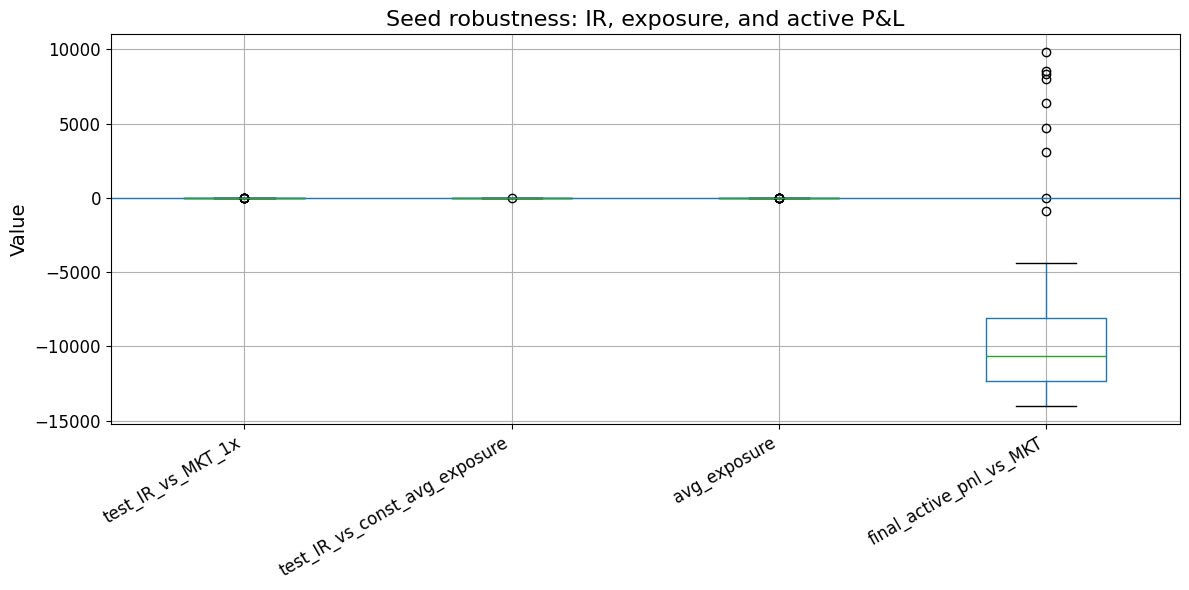

In [39]:
plot_cols = [
    "test_IR_vs_MKT_1x",
    "test_IR_vs_const_avg_exposure",
    "avg_exposure",
    "final_active_pnl_vs_MKT",
]

plot_cols = [c for c in plot_cols if c in seed_results.columns]

plt.figure(figsize=(12, 6))
seed_results[plot_cols].boxplot()
plt.axhline(0, linewidth=1)
plt.ylabel("Value", fontsize=14)
plt.title("Seed robustness: IR, exposure, and active P&L", fontsize=16)
plt.xticks(rotation=30, ha="right", fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()
